# End-to-End Vulnerability Analysis on MDOF System using Multiple Stripe Analysis

## Introduction

This Jupyter Notebook provides a structured workflow for performing Multiple Stripe Analysis (MSA) on multi-degree-of-freedom (MDOF) stick-and-mass models. MSA subjects a structural model to distinct "stripes" of ground motion records, where each stripe is specifically selected or scaled to represent the unique frequency content and hazard characteristics at a predefined intensity level. This produces a discrete statistical distribution of structural responses (e.g., maximum interstorey drift) at specific intensity increments (e.g., spectral acceleration), providing a robust probabilistic view of building performance.

The main goals of this notebook:

1. **Calibrate MDOF models based on single-degree-of-freedom (SDOF) oscillator capacity**: Calibrate storey-based force-deformation relationships using SDOF capacity curve definition (spectral displacement-spectral acceleration)

2. **Perform MSA**: Subject the model to sets of ground motions at discrete intensity levels (stripes) corresponding to multiple return periods. MSA typically uses different hazard-consistent ground motion suites at different intensities, usually selected using the conditional spectrum method to better account for the varying spectral shapes and hazard characteristics expected at low versus high return periods.

3. **Fragility Analysis via Maximum Likelihood (MLE)**: Postprocess the "stripes" to determine the capacity of the structure at various limit states. Because MSA results in a set of successful versus collapsed simulations at each level, we use statistical methods such as MLE to construct fragility functions that describe the probability of exceeding a damage state as a function of ground-shaking intensity.

4. **Vulnerability Analysis**: Integrate these fragility functions with consequence models (i.e., damage-to-loss models) to determine the continuous relationship between a decision variable (such as repair cost ratio) and increasing levels of ground-shaking intensities.

The notebook provides a step-by-step guide, covering each phase from MDOF model creation and ground motion suite organization to analysis execution and detailed results extraction. Users should have some familiarity with Python scripting, structural dynamics, computational modeling, and performance-based earthquake engineering to fully benefit from this material.

## References

[1] Jalayer F. and Cornell C.A. (2009). Alternative Nonlinear Demand Estimation Methods for Probability-Based Seismic Assessments, Earthquake Engineering and Structural Dynamics, 38(8): pp. 951-972.

[2] Jalayer F. (2003). Direct Probabilistic Seismic Analysis: Implementing Non-linear Dynamic Assessments, Ph.D. Thesis, Department of Civil and Environmental Engineering, Stanford, CA.

[3] Lin, T., Haselton, C.B. and Baker, J.W. (2013), Conditional spectrum-based ground motion selection. Part I: Hazard consistency for risk-based assessments. Earthquake Engng Struct. Dyn., 42: 1847-1865. https://doi.org/10.1002/eqe.2301

[4] Lin, T., Haselton, C.B. and Baker, J.W. (2013), Conditional spectrum-based ground motion selection. Part II: Intensity-based assessments and evaluation of alternative target spectra. Earthquake Engng Struct. Dyn., 42: 1867-1884. https://doi.org/10.1002/eqe.2303

[5] Bazzurro, P., Cornell, A. (1999), Disaggregation of seismic hazard. Bulletin of the Seismological Society of America; 89 (2): 501–520. doi: https://doi.org/10.1785/BSSA0890020501

[6] Baker JW. Efficient Analytical Fragility Function Fitting Using Dynamic Structural Analysis. Earthquake Spectra. 2015;31(1):579-599. doi:10.1193/021113EQS025M

[7] Pagani, M., Monelli, D.,  Weatherill, G., Danciu, L., Crowley, H., Silva, V., Henshaw, P., Butler, L., Nastasi, M., Panzeri, L., Simionato, M., Vigano, D., (2014) OpenQuake Engine: An Open Hazard (and Risk) Software for the Global Earthquake Model. Seismological Research Letters; 85 (3): 692–702. doi: https://doi.org/10.1785/0220130087

[8] Rao A, Yepes-Estrada C, Johnson K, et al. Evolution of the OpenQuake Engine: Enhanced capabilities, collaborative development, and global adoption. Earthquake Spectra. 2025;41(5):3299-3336. doi:10.1177/87552930251378157

## Initialize Libraries ##

In [1]:
import os
import numpy as np

from openquake.vmtk.units import units
from openquake.vmtk.plotter import plotter
from openquake.vmtk.modeller import modeller
from openquake.vmtk.utilities import export_to_pkl
from openquake.vmtk.imcalculator import imcalculator
from openquake.vmtk.postprocessor import postprocessor
from openquake.vmtk.calibration import calibrate_model

## Define Directories ##

In [2]:
# Define the directory of the ground-motion records
gm_directory = './in/records'

# Define the main output directory
msa_directory = './out'
os.makedirs(msa_directory, exist_ok=True)

## Load Hazard-Consistent Acceleration Time-Histories and Process Intensity Measures ## 

The suite of ground‐motion records was selected using the **Conditional Mean Spectrum (CMS) method** [3,4], based on a **hazard disaggregation analysis** [5] performed for a site located in **Lisbon, Portugal**, using the **OpenQuake Engine** [7,8]. Classical probabilistic seismic hazard assessment is carried out to identify the intensity measure (IM) levels at each user-defined return period. The disaggregation results were used to identify the controlling earthquake scenarios (magnitude–distance–epsilon) associated with the target hazard levels. Additional information, such as demos and documentation, on performing hazard disaggregation in OpenQuake is available in the official repository (accessible on: https://github.com/gem/oq-engine/tree/master/demos/hazard/Disaggregation) and documentation (accessible on: https://docs.openquake.org/oq-engine/manual/latest/user-guide/outputs/disaggregation-outputs.html), respectively.

The record selection was conditioned on the **spectral acceleration at the fundamental period, $SA(T_{1})$** of the case-study **multi-degree-of-freedom (MDOF) stick model**, with a fundamental period of **T ≈ 0.19 s**. Separate sets of ground-motion records were selected to represent different seismic hazard levels corresponding to distinct return periods (i.e., from 22 to 9475 years). This approach ensures comprehensive coverage of the structural response domain, from the onset of yielding and nonlinear behavior to collapse mechanisms or dynamic instability.

**Figure 1** presents the ground-motion records selected for a **return period of 42 years**, while **Figure 2** shows the records selected for a **return period of 975 years**, representing rare, high-intensity seismic events.

<p align="center">
  <img src="./in/records/42/Selected.png" width="60%">
  <br>
  <strong>Figure 1.</strong> Ground-motion records conditioned at $SA(T_{1}=0.19s)$ and selected for a site in L'Aquila, Italy using the CMS method for a return period of 42 years.
</p>

<p align="center">
  <img src="./in/records/975/Selected.png" width="60%">
  <br>
  <strong>Figure 2.</strong> Ground-motion records conditioned at $SA(T_{1}=0.19s)$ and selected for a site in L'Aquila, Italy using the CMS method for a return period of 975 years.
</p>

In [3]:
# Input the intensity measure types required for processing
IMT = ['SA(0.19)']

# Input return periods
RP = ['22', '42', '72', '140', '224', '475', '975', '2475', '4975']

# Initialise hierarchical IM storage
imls = {rp: {imt: [] for imt in IMT} for rp in RP}

# Loop over return periods
for current_rp in RP:

    # Current return period folder
    current_rp_folder = os.path.join(gm_directory, current_rp)

    # Load ground-motion data: acceleration time-histories, time-steps and durations
    gmrs = np.loadtxt(os.path.join(current_rp_folder, 'GMR_H1_names.txt'), dtype=str).flatten()
    dts = np.loadtxt(os.path.join(current_rp_folder, 'GMR_dts.txt'), dtype=float)

    # Loop over ground-motion records per return period
    for i in range(len(gmrs)):

        # Load acceleration time history and time-step
        current_gmr_name = gmrs[i]
        current_acc = np.loadtxt(os.path.join(current_rp_folder, f'{current_gmr_name}'))
        current_dt = dts[i]

        # Initialise the IM calculator
        im_calc = imcalculator(current_acc, current_dt)

        # Calculate the spectral acceleration at the conditioning period
        T_star = 0.19
        sa019 = im_calc.get_sa(T_star)

        # Store IMs by return period: this will be then used in NLTHA for MSA
        imls[current_rp]['SA(0.19)'].append(sa019)

# Export to pickle format
export_to_pkl(os.path.join(gm_directory, 'imls_Lisbon.pkl'), imls)

## Calibrate and Compile an MDOF Model based on SDOF Capacity ##

In [4]:
# Number of storeys
number_storeys = 2

# Relative floor heights list
storey_heights = [2.80, 2.80]

# SDOF capacity with a quadrilinear backbone
sdof_capacity = np.array(
    [[0.00060789, 0.00486316, 0.02420000, 0.04353684],  # spectral displacement [m]
     [0.10315200, 0.20630401, 0.12378241, 0.12502023]]  # spectral acceleration [g]
).T

# Soft-storey mechanism flag
isSOS = False

# Degradation flag
mdof_degradation = True

# Calibrate the model
floor_masses, storey_drifts, storey_forces, _, _ = calibrate_model(
    number_storeys,
    sdof_capacity,
    is_sos=isSOS,
    storey_heights=storey_heights,
    verbose=False,
)

~~~~~~~ ANALYSIS SUCCESSFUL! ~~~~~~~~~


WARNING ZeroLength::setDomain(): Element 2000 has L= 1, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 1, which is greater than the tolerance


## Setting Up, Running MSAs and Exporting Analysis ##

In the next code snippet, MSA is carried out on the stick model using the selected hazard-consistent record sets.

For each ground-motion record, the MDOF model is compiled, gravity-loaded, and subjected to modal analysis to extract its dynamic properties. The ground motion is then applied through NLTHA using consistent time-stepping, appropriate unit scaling, and specified damping.

The analysis extracts key engineering demand parameters (EDPs), including peak storey drifts, peak floor accelerations, and peak floor displacements along the building height. Maximum response values, together with their associated directions and locations, are also recorded. Numerical convergence is monitored through a convergence index.

All response quantities are stored for each record and aggregated into a structured dataset, which is exported for subsequent fragility development, and vulnerability analysis.

======== MSA Analysing RP:22 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


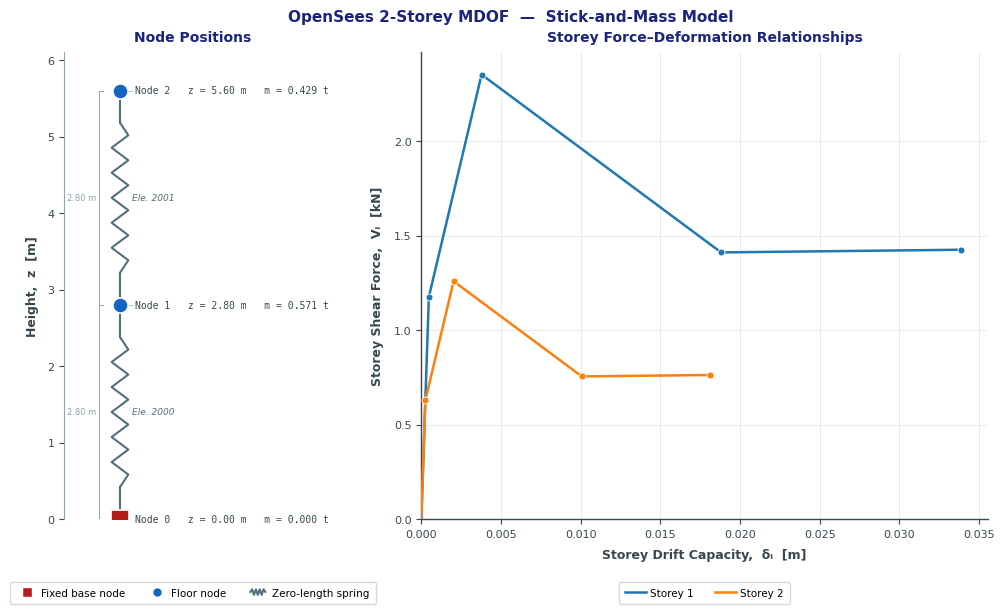

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [7.63028935e-05 6.34060563e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.005619456177325926), np.float64(0.005525109023927961), np.float64(0.008107752341721295)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 7.630289348311099e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.008107752341721295 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 2 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [8.14964876e-05 5.88002754e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0027388943215573666), np.float64(0.0049550514188982705), np.float64(0.0068817138189055035)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 8.149648756358658e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0068817138189055035 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 3 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [4.66426298e-05 2.13515681e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0016951150439142241), np.float64(0.0020495259187751744), np.float64(0.00235676678422759)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 4.6642629835532814e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.00235676678422759 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 4 out of 20 =========


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [3.63661800e-05 2.60628743e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0011632145470990732), np.float64(0.002281074461587392), np.float64(0.0033426668504985243)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 3.6366180027191e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0033426668504985243 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 19 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [4.88583923e-05 1.76135487e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0017076165970667959), np.float64(0.0027537838098519564), np.float64(0.0030709300094508064)] g
Peak acceleration values in Y-dire

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [6.04335811e-05 2.96913218e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.00226902280926663), np.float64(0.0030272603773899617), np.float64(0.0036757551589270887)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 6.043358109954844e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0036757551589270887 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


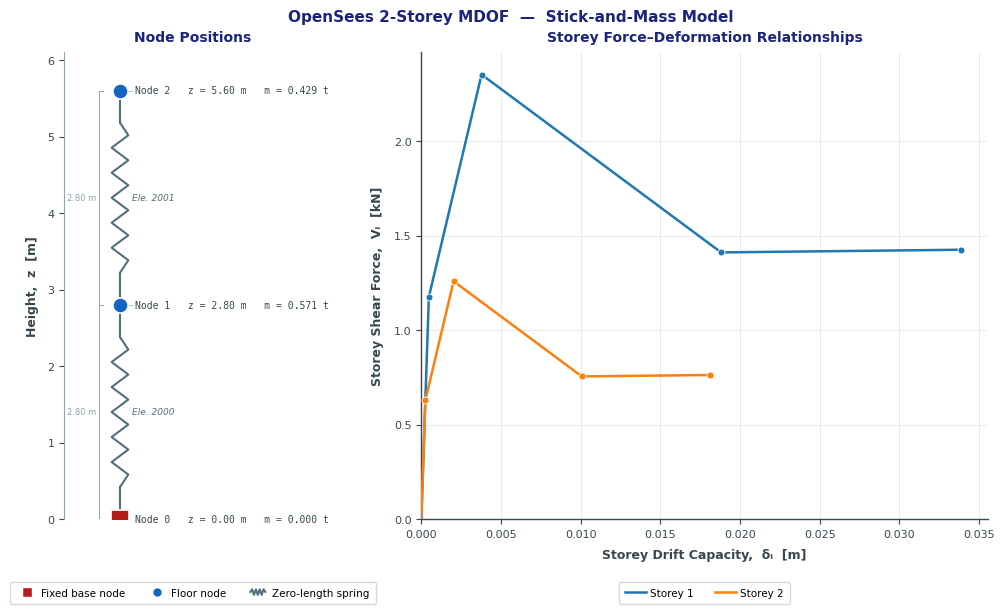

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.27829524e-04 6.61710807e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.007581990435505261), np.float64(0.008175831336804697), np.float64(0.008346003150646663)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00012782952420772775 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.008346003150646663 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 2 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [7.02498735e-05 6.44608423e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0024153780316839998), np.float64(0.0058419421077837335), np.float64(0.008005494930357475)] g
Peak acceleration values in Y-direct

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [9.49646806e-05 4.98838698e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0034357595646649216), np.float64(0.005220432496751751), np.float64(0.0070046678724795305)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 9.4964680617804e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0070046678724795305 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 5 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.02595780e-04 5.59672688e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0028929777078859683), np.float64(0.0052967951761454125), np.float64(0.007955457201388369)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00010259577981065126 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.007955457201388369 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 19 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [9.67364886e-05 6.45096315e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0029851562273939323), np.float64(0.0052010983586898984), np.float64(0.007945019627010733)] g
Peak acceleration values in Y-dir

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00016647 0.0001066 ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.004455525624748545), np.float64(0.010558859441218647), np.float64(0.015048936374736026)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00016647186334133022 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.015048936374736026 encountered in X direction on storey # 2
======== MSA Analysing RP:72 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


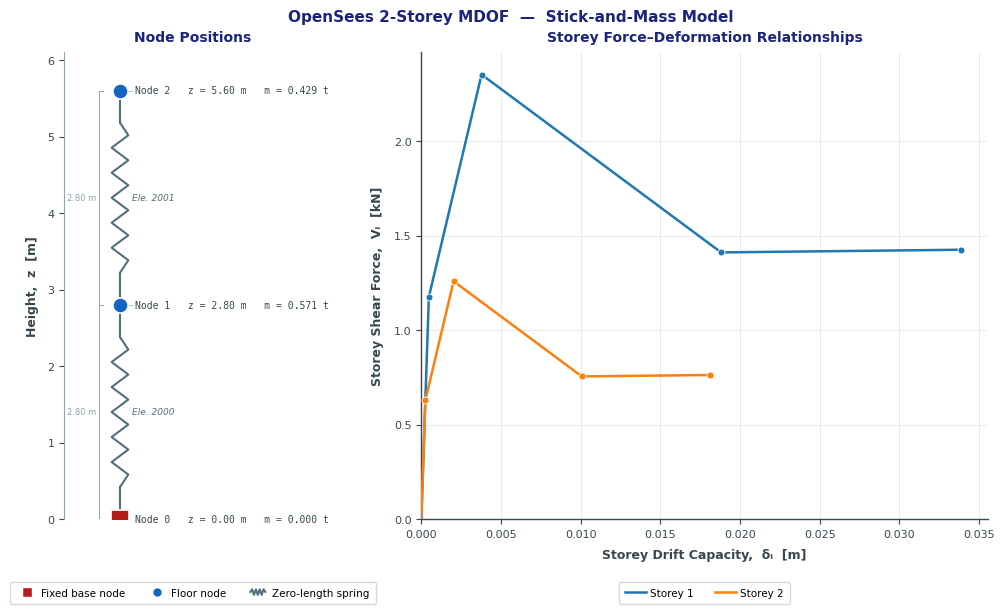

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0001938  0.00012582] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.003948309423499632), np.float64(0.010768977898847586), np.float64(0.016110865305302424)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00019379591519734138 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.016110865305302424 encountered in X direction on storey # 2
======== MSA Analysing RP:72 years, Record 2 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.65404495e-04 9.08065727e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.016857719227800272), np.float64(0.009032967555735868), np.float64(0.015312906682773589)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00016540449508012305 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.016857719227800272 encountered in X direction on storey # 0
======== MSA Analysing RP:72 years, Record 3 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.76344041e-04 6.98722067e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.003756194793546049), np.float64(0.012088040780998614), np.float64(0.011437372184960432)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00017634404107108383 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.012088040780998614 encountered in X direction on storey # 1
======== MSA Analysing RP:72 years, Record 4 out of 20 =========


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00028544 0.00014838] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0061062681652725385), np.float64(0.012396027518707279), np.float64(0.01695171192001686)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00028544346687162553 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.01695171192001686 encountered in X direction on storey # 2
======== MSA Analysing RP:72 years, Record 20 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.79738385e-04 9.05794258e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.004875380918666178), np.float64(0.010307376685955341), np.float64(0.013809127438949017)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00017973838473512888 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.013809127438949017 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


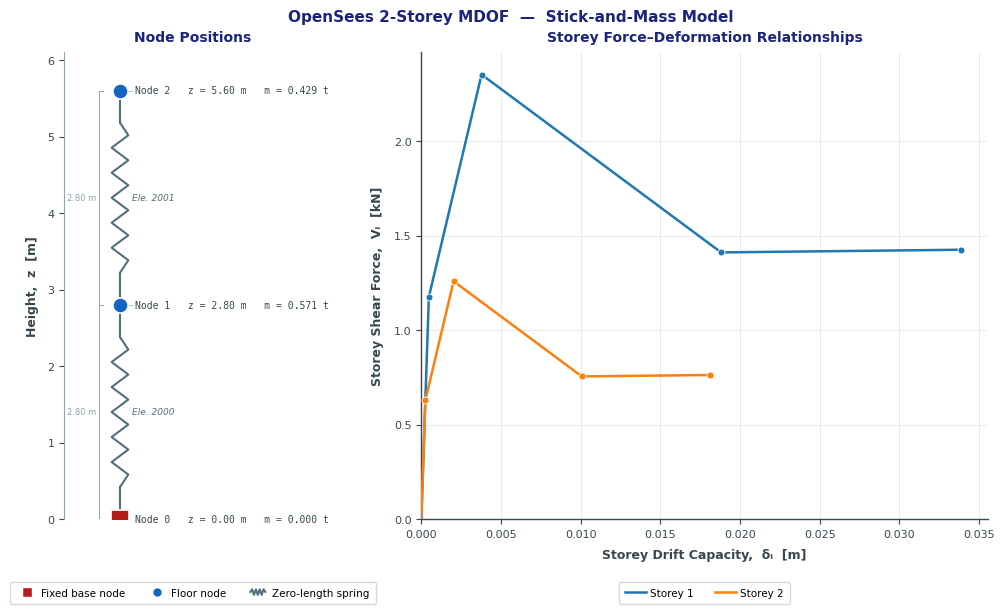

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00040503 0.00023612] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.009536686210338605), np.float64(0.014230761138020605), np.float64(0.018495919607481627)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0004050259947861508 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.018495919607481627 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 2 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0003061  0.00013237] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.006404449810440932), np.float64(0.0136135477740937), np.float64(0.016014126784789768)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0003061019592663267 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.016014126784789768 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 3 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00021072 0.0001985 ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.006188241685533911), np.float64(0.013195021041526967), np.float64(0.017141719596618442)] g
Peak acceleration values in Y-direction: [np.float64(0.0

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.37717917e-04 9.60898290e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.004809399248339304), np.float64(0.009587497946283158), np.float64(0.013059946707335556)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00013771791692699024 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.013059946707335556 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 5 out of 20 =========


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00044189 0.00012707] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.008065624419786631), np.float64(0.014199491829109305), np.float64(0.016869730755689566)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0004418923695544956 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.016869730755689566 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 20 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00031092 0.00036975] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.009750816272112026), np.float64(0.01966325100335406), np.float64(0.02087237433682343)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00036974641356200436 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.02087237433682343 encountered in X direction on storey # 2
======== MSA Analysing RP:224 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


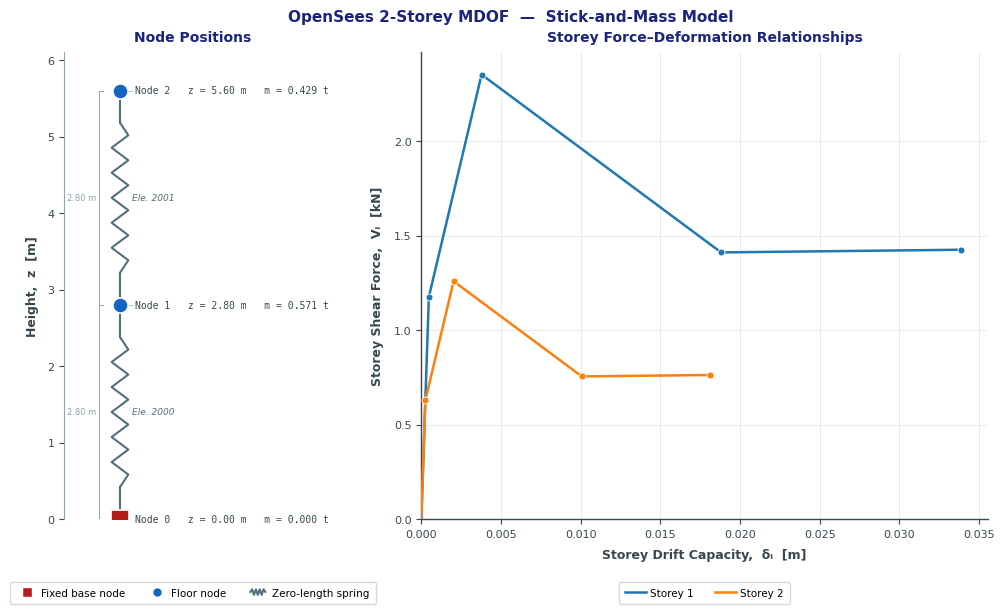

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00045042 0.00029934] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.015052138743474273), np.float64(0.016942825416585358), np.float64(0.019700630784382722)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0004504219808978403 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.019700630784382722 encountered in X direction on storey # 2
======== MSA Analysing RP:224 years, Record 2 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00050791 0.00019932] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.00811085786820327), np.float64(0.01771614416394289), np.float64(0.017786253604225744)] g
Peak acceleration values in Y-direction: [np.float64(0.0

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00048048 0.00015693] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.008386459819483542), np.float64(0.018541838031976458), np.float64(0.01704220247400198)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00048047675165905154 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.018541838031976458 encountered in X direction on storey # 1
======== MSA Analysing RP:224 years, Record 4 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00040116 0.00056981] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.013235569257028163), np.float64(0.020222381898874684), np.float64(0.025322222180327852)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0005698095559302283 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.025322222180327852 encountered in X direction on storey # 2
======== MSA Analysing RP:224 years, Record 19 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00074665 0.00030048] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.011351684349361712), np.float64(0.018397288695935876), np.float64(0.019464759871765193)] g
Peak acceleration values in Y-direction: [np.float64(

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00071867 0.0003154 ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.018884223861846676), np.float64(0.019376602163225363), np.float64(0.01977312421121446)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0007186731269613305 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.01977312421121446 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


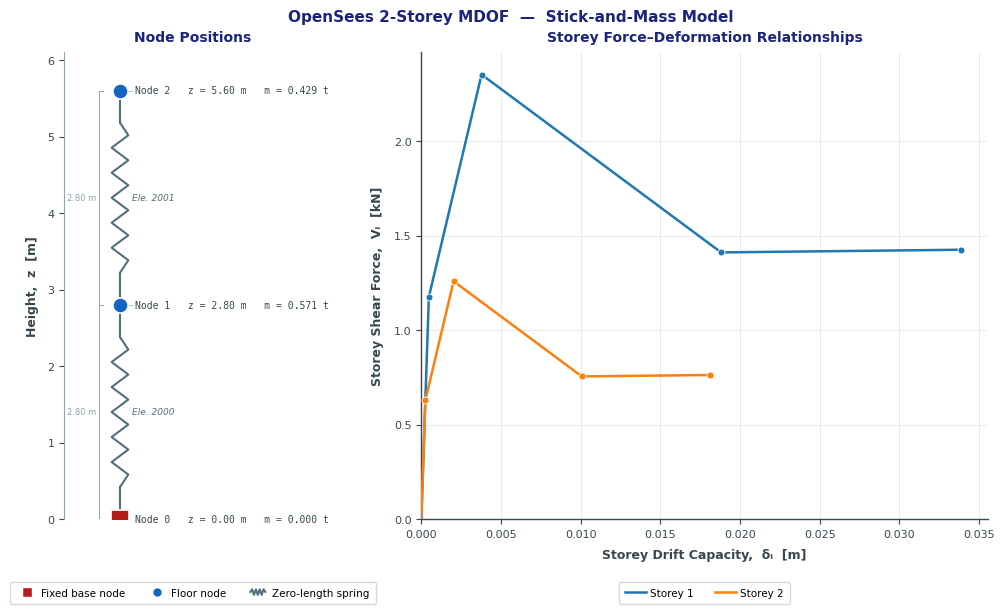

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00060361 0.00038489] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.02060244794556053), np.float64(0.017550848161664048), np.float64(0.021559643071644707)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0006036096986869797 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.021559643071644707 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 2 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00070664 0.00047745] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.012817156161800092), np.float64(0.020353734552375154), np.float64(0.023512752114904154)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0007066440004332931 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.023512752114904154 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 3 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00116406 0.00040503] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.016809047596618602), np.float64(0.0229559487144102), np.float64(0.02160024576363612)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0011640623335234465 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0229559487144102 encountered in X direction on storey # 1
======== MSA Analysing RP:475 years, Record 4 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00080651 0.00028936] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.015694794981456827), np.float64(0.018233186838587996), np.float64(0.019702863445423227)] g
Peak acceleration values in Y-direction: [np.float64(0.0), 

...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00272034 0.00086308] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03160334317719029), np.float64(0.03175797820819206), np.float64(0.031554490047648646)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0027203440636773385 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.03175797820819206 encountered in X direction on storey # 1
======== MSA Analysing RP:475 years, Record 18 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00190917 0.00123063] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.02398868040195061), np.float64(0.029173062944862355), np.float64(0.03343130306814586)] g
Peak acceleration values in Y-direction: [np.float64(0.0),

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00088142 0.00059151] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.016531039949337578), np.float64(0.023048310282703214), np.float64(0.02595399196967406)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.000881419693472034 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.02595399196967406 encountered in X direction on storey # 2
======== MSA Analysing RP:975 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


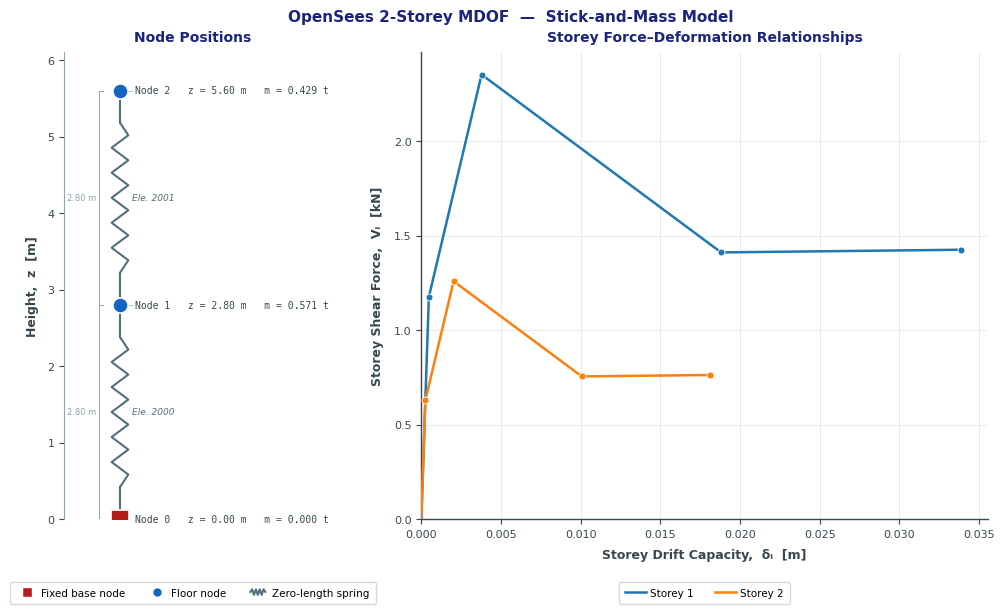

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0494673  0.03267696] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03927945122840653), np.float64(0.03973836933429656), np.float64(0.03129470794174554)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.049467300640802465 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.03973836933429656 encountered in X direction on storey # 1
======== MSA Analysing RP:975 years, Record 2 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00072172 0.00052002] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03013916778754476), np.float64(0.02261704524950834), np.float64(0.024650944924783175)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00075618 0.00076681] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.01198386030141546), np.float64(0.024165214548715206), np.float64(0.027285076508716734)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0007668077648448731 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.027285076508716734 encountered in X direction on storey # 2
======== MSA Analysing RP:975 years, Record 4 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00140646 0.00151966] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.020896391661301854), np.float64(0.03439798571418649), np.float64(0.033436163339131866)] g
Peak acceleration values in Y-direction: [np.float64(0.0

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00097689 0.00070277] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.023427969981867372), np.float64(0.024287358746183825), np.float64(0.028493264010788385)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0009768939971807082 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.028493264010788385 encountered in X direction on storey # 2
======== MSA Analysing RP:975 years, Record 6 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00130078 0.00054479] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.046763351267315), np.float64(0.025541949875608), np.float64(0.02563714368017107)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np

...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00828435 0.00274742] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.02849638519249279), np.float64(0.038917204000345144), np.float64(0.03446314819561916)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00828435281780502 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.038917204000345144 encountered in X direction on storey # 1
======== MSA Analysing RP:975 years, Record 17 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00103402 0.00073848] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.017553967287959372), np.float64(0.024020338445774572), np.float64(0.027218325201511413)] g
Peak acceleration values in Y-direction: [np.float64(0.0)

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00118865 0.00130005] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.02168776013867956), np.float64(0.03392800118815881), np.float64(0.02891250124515898)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0013000478405416098 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.03392800118815881 encountered in X direction on storey # 1
======== MSA Analysing RP:975 years, Record 19 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00133515 0.0011789 ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.05463349509256796), np.float64(0.03320997053059611), np.float64(0.029890958783189463)] g
Peak acceleration values in Y-direction: [np.float64(0.0), 

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


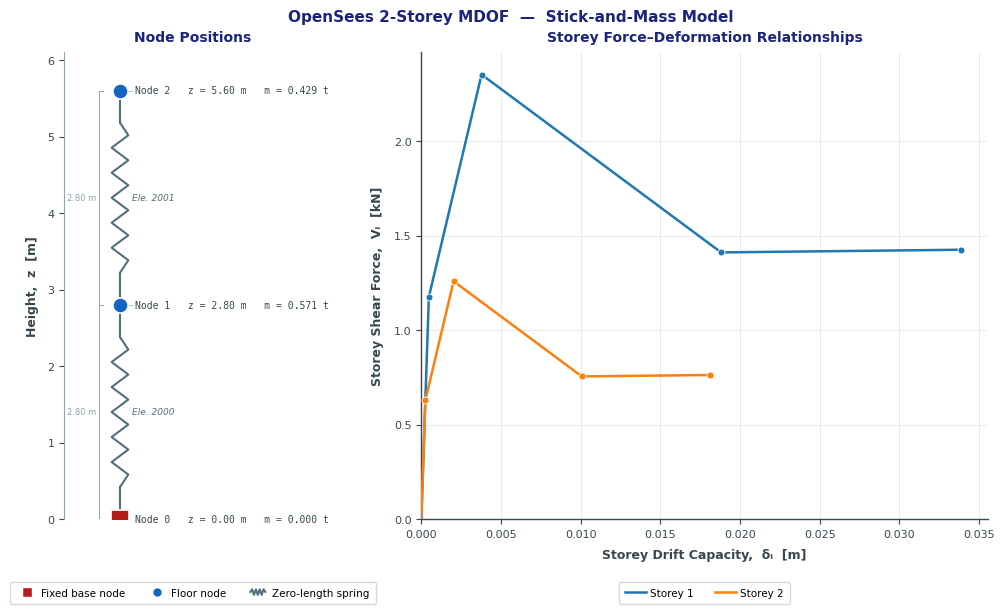

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.06128239 0.04064619] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.04491681206859118), np.float64(0.03532460891589312), np.float64(0.03219622029865861)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.06128239486096223 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.04491681206859118 encountered in X direction on storey # 0
======== MSA Analysing RP:2475 years, Record 2 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00079481 0.0008259 ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.02543690311548308), np.float64(0.025311893494369794), np.float64(0.02731264243593195)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0008258973982452149 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.02731264243593195 encountered in X direction on storey # 2
======== MSA Analysing RP:2475 years, Record 3 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00222522 0.00273875] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.02185334649153309), np.float64(0.03232691838613181), np.float64(0.03229631189639044)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0027387454055411995 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.03232691838613181 encountered in X direction on storey # 1
======== MSA Analysing RP:2475 years, Record 4 out of 20 =========


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00136106 0.00099468] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.032477543168900905), np.float64(0.03235416923236791), np.float64(0.032578753333125834)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0013610594579826676 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.032578753333125834 encountered in X direction on storey # 2
======== MSA Analysing RP:2475 years, Record 20 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0009705 0.0005443] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.018501609476819985), np.float64(0.021854418645222407), np.float64(0.02469863112062985)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0009704955191713804 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.02469863112062985 encountered in X direction on storey # 2
======== MSA Analysing RP:4975 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


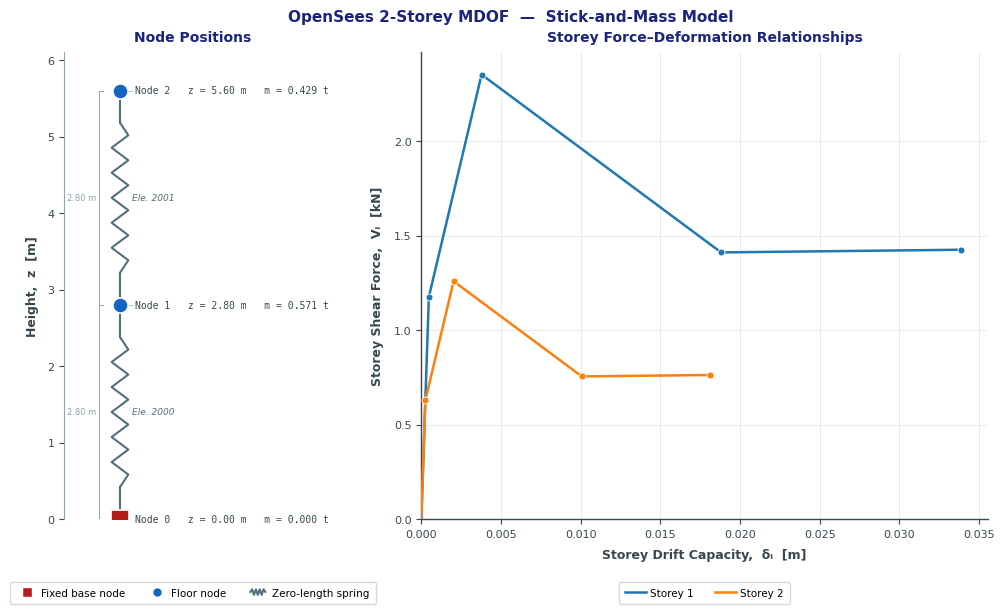

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00160049 0.00088773] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.041717943223647885), np.float64(0.028695339900772176), np.float64(0.032045303340560265)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.001600490224585462 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.041717943223647885 encountered in X direction on storey # 0
======== MSA Analysing RP:4975 years, Record 2 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00105761 0.00100293] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03209094672135143), np.float64(0.028888670186112044), np.float64(0.027531270531275142)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.001057607520960408 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.03209094672135143 encountered in X direction on storey # 0
======== MSA Analysing RP:4975 years, Record 3 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00213149 0.00070371] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03752497268517217), np.float64(0.02963006685124303), np.float64(0.029516563400285977)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0021314934143132373 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.03752497268517217 encountered in X direction on storey # 0
======== MSA Analysing RP:4975 years, Record 4 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00206193 0.0007295 ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03503734466966091), np.float64(0.028492073249781688), np.float64(0.03096016973782656)] g
Peak acceleration values in Y-direction: [np.float64(0.0),

...

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00663427 0.00086213] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.04298931864837716), np.float64(0.034006420865522434), np.float64(0.035808542005763624)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.006634266481180184 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.04298931864837716 encountered in X direction on storey # 0
======== MSA Analysing RP:4975 years, Record 15 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00497746 0.00104242] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.04170595202758898), np.float64(0.03321337556718284), np.float64(0.03487775222255454)] g
Peak acceleration values in Y-direction: [np.float64(0.0),

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.08528618 0.04148403] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.07718300541919665), np.float64(0.03918239148542379), np.float64(0.03245139081069952)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.08528617676709477 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.07718300541919665 encountered in X direction on storey # 0
======== MSA Analysing RP:4975 years, Record 19 out of 20 =========
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00467897 0.002396  ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.05233386228719571), np.float64(0.03984622907053), np.float64(0.037431969193441675)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.f

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.01193308 0.00144237] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03828944507783191), np.float64(0.039657131734830514), np.float64(0.03531538188348258)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.011933083756638027 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.039657131734830514 encountered in X direction on storey # 1
ANALYSIS COMPLETED!


In [5]:
# Initialise the hierarchical dictionary
ansys_dict = {}

# Loop over return periods
for current_rp in RP:

    # Current return period folder
    current_rp_folder = os.path.join(gm_directory, str(current_rp))

    # Load ground-motion data: acceleration time-histories, time-steps and durations
    gmrs = np.loadtxt(os.path.join(current_rp_folder, 'GMR_H1_names.txt'), dtype=str)
    dts = np.loadtxt(os.path.join(current_rp_folder, 'GMR_dts.txt'), dtype=float)

    # Initialise storage for this return period
    ansys_dict[current_rp] = {
        'conv_index_list': [],
        'peak_disp_list': [],
        'peak_drift_list': [],
        'peak_accel_list': [],
        'max_peak_drift_list': [],
        'max_peak_drift_dir_list': [],
        'max_peak_drift_loc_list': [],
        'max_peak_accel_list': [],
        'max_peak_accel_dir_list': [],
        'max_peak_accel_loc_list': [],
    }

    # Loop over ground-motion records
    for i in range(len(gmrs)):
        print('================================================================')
        print(
            '======== MSA Analysing RP:{:s} years, Record {:d} out of {:d} ========='.format(
                current_rp,
                i +
                1,
                len(gmrs)))
        print('================================================================')

        # Initialise the modeller class and compile the MDOF model
        model = modeller(number_storeys,
                         storey_heights,
                         floor_masses,
                         storey_drifts,
                         storey_forces * units.g,
                         mdof_degradation)
        model.compile_model()

        # Plot the model only for the first ground-motion record
        if i == 0:
            model.plot_model()

        # Do gravity analysis for system equilibrium
        model.do_gravity_analysis()

        # Do modal analysis
        num_modes = 1 if number_storeys == 1 else 3
        model.do_modal_analysis(num_modes=num_modes, plot_modes=False)

        # Define ground motion objects
        fnames = [os.path.join(current_rp_folder, f'{gmrs[i]}')]
        current_acc = np.loadtxt(os.path.join(current_rp_folder, gmrs[i]))
        dt_gm = dts[i]
        t_max = len(current_acc) * dt_gm
        dt_ansys = dt_gm  # Set the analysis time-step equal to the ground-motion time-step

        # Run Multiple Stripe Analysis:
        # There is no dedicated function in OQ-VMTK for MSA; we call do_nrha_analysis
        # for each record at each return period
        (_, conv_index, peak_drift, peak_accel,
         max_peak_drift, max_peak_drift_dir, max_peak_drift_loc,
         max_peak_accel, max_peak_accel_dir, max_peak_accel_loc,
         peak_disp, _, _) = model.do_nrha_analysis(
            fnames,
            dt_gm,
            units.g,
            t_max,
            dt_ansys,
            pFlag=False,
            xi=0.05,
        )

        # Print results
        print('Peak drift values in X-direction:', peak_drift[:, 0], 'rad')
        print('Peak drift values in Y-direction:', peak_drift[:, 1], 'rad')
        print('Peak acceleration values in X-direction:', [x / 9.81 for x in peak_accel[:, 0]], 'g')
        print('Peak acceleration values in Y-direction:', [x / 9.81 for x in peak_accel[:, 1]], 'g')
        print('Maximum peak storey drift value of', max_peak_drift, 'encountered in',
              max_peak_drift_dir, 'direction', 'on storey #', max_peak_drift_loc)
        print('Maximum peak floor acceleration value of', max_peak_accel / 9.81, 'encountered in',
              max_peak_accel_dir, 'direction', 'on storey #', max_peak_accel_loc)

        # Store results in hierarchical dict
        ansys_dict[current_rp]['conv_index_list'].append(conv_index)
        ansys_dict[current_rp]['peak_drift_list'].append(peak_drift)
        ansys_dict[current_rp]['peak_accel_list'].append(peak_accel)
        ansys_dict[current_rp]['peak_disp_list'].append(peak_disp)
        ansys_dict[current_rp]['max_peak_drift_list'].append(max_peak_drift)
        ansys_dict[current_rp]['max_peak_drift_dir_list'].append(max_peak_drift_dir)
        ansys_dict[current_rp]['max_peak_drift_loc_list'].append(max_peak_drift_loc)
        ansys_dict[current_rp]['max_peak_accel_list'].append(max_peak_accel)
        ansys_dict[current_rp]['max_peak_accel_dir_list'].append(max_peak_accel_dir)
        ansys_dict[current_rp]['max_peak_accel_loc_list'].append(max_peak_accel_loc)

# Export the results
export_to_pkl(os.path.join(msa_directory, 'msa_ansys_out.pkl'), ansys_dict)

print('ANALYSIS COMPLETED!')

## Pre-Process Intensity Measure Levels and Engineering Demand Parameters for MSA Post-Processor ##

In [6]:
# Determine dimensions
# The number of stripes equals the number of return periods considered
num_stripes = len(RP)
# The number of ground-motion is equal across all return periods (so we
# can simply take the length of the first RP IML values)
num_gmrs = len(imls[RP[0]]['SA(0.19)'])

# Initialize empty arrays
imls_matrix = np.zeros((num_gmrs, num_stripes))
edps_matrix = np.zeros((num_gmrs, num_stripes))

# Loop over RPs to fill the columns
for j, rp in enumerate(RP):
    # Use the dictionary (imls) to fill the array (imls_matrix)
    # The input is the name of the key associated with the IMT (IMT[0] = 'SA(0.2)')
    imls_matrix[:, j] = imls[rp][IMT[0]]
    # Options are: 'max_peak_drift_list' or 'max_peak_accel_list'
    edps_matrix[:, j] = ansys_dict[rp]['max_peak_drift_list']

## Post-Process Multiple Stripe Results: Maximum Likelihood Estimation and Fragility Functions ##

**Multiple Stripe Analysis** [1,2] is an efficient computational procedure used to assess the seismic performance of structures at discrete levels of intensity. MSA involves using a set of hazard-consistent ground motion ensembles [3] at specific intensity measure (IM) levels, or "stripes". These stripes typically correspond to distinct hazard levels, such as specific return periods or targets defined by an "approximate" or "exact" Conditional Mean Spectrum (CMS) [4] in tandem with the results of seismic hazard disaggregation [5]. The CMS can be calculated using the OpenQuake Engine [7,8]. Additional information, such as examples and documentation, on performing hazard disaggregation in OpenQuake is available in the official repository (accessible on: https://github.com/gem/oq-engine/tree/master/openquake/qa_tests_data/conditional_spectrumn) and documentation (accessible on: https://docs.openquake.org/oq-engine/LTS/manual/user-guide/advanced/advanced-calculations.html), respectively. The primary output of MSA for fragility assessment is a set of discrete data points: at each intensity level , a total of ground motions are analyzed, and the number of cases exceeding a specific damage state (e.g., collapse) is recorded.

A primary advantage of MSA is its ability to explicitly decouple the intensity measure from the record-selection process at each hazard level. This allows researchers to account for the evolution of spectral shape and ground motion characteristics (e.g., epsilon, duration) as seismic intensity increases. By analyzing structural response distributions at these discrete intervals, MSA captures the aleatory uncertainty (record-to-record variability) and provides the statistical basis for deriving fragility functions through Maximum Likelihood Estimation (MLE) [6].

### Fragility Function Derivation using Maximum Likelihood Estimation ###

To translate these discrete observations into a continuous, statistically robust fragility function, MLE is employed. This approach, as detailed by Baker [4], treats the structural response at each stripe as a series of Bernoulli trials, where the outcome is either exceeding or not exceeding a specific limit state.

#### Step 1: The Lognormal Distribution Assumption #### 

The fragility function represents the probability of exceeding a damage state ($DS$) conditioned on the intensity measure ($IM$). It is conventionally modeled using a lognormal cumulative distribution function (CDF):$$P(DS \ge ds \mid IM = im) = \Phi \left( \frac{\ln(im / \mu)}{\beta} \right)$$ where: 
* $\mu$ is the median capacity (the intensity level with a 50% probability of exceedance)
* $\beta$ is the logarithmic standard deviation (dispersion) representing record-to-record variability
* $\Phi(\cdot)$ denotes the standard normal cumulative distribution function.

#### Step 2: Formulating the Likelihood Function #### 

The objective of MLE is to find the parameters $\mu$ and $\beta$ that maximize the likelihood of observing the data obtained from the MSA. For a set of $m$ stripes, the likelihood function $\mathcal{L}$ is the product of the binomial probabilities for each stripe:$$\mathcal{L} = \prod_{j=1}^{m} \binom{n_j}{z_j} \left[ \Phi \left( \frac{\ln(im_j / \mu)}{\beta} \right) \right]^{z_j} \left[ 1 - \Phi \left( \frac{\ln(im_j / \mu)}{\beta} \right) \right]^{n_j - z_j}$$In practice, it is numerically more stable to maximize the log-likelihood ($\ln \mathcal{L}$), which converts the product into a sum:$$\ln \mathcal{L} = \sum_{j=1}^{m} \left\{ \ln \binom{n_j}{z_j} + z_j \ln \left[ \Phi \left( \frac{\ln(im_j / \mu)}{\beta} \right) \right] + (n_j - z_j) \ln \left[ 1 - \Phi \left( \frac{\ln(im_j / \mu)}{\beta} \right) \right] \right\}$$

#### Step 3: Optimization and Total Uncertainty #### 

The optimal estimates for the median (${\mu}$) and dispersion (${\beta}$) are obtained by solving the optimization problem that maximizes the log-likelihood function. This method is particularly robust because it utilizes the full data set, including stripes where zero or all records exceed the damage state, without the bias inherent in extrapolating regressions from non-collapse data.The total dispersion $\beta_{DS_i}^{\text{total}}$ is then computed by incorporating epistemic uncertainties using the root sum of squares (SRSS):$$\beta_{DS_i}^{\text{total}} = \sqrt{\beta_{\text{record-to-record}}^2 + \beta_{\text{building-to-building}}^2 + \beta_{\text{DS}}^2}$$ where: 
* $\beta_{\text{record-to-record}}$ is the dispersion derived from the record-to-record variability in the MSA
* $\beta_{\text{building-to-building}}$ captures variability in structural properties across nominally similar buildings
* $\beta_{\text{DS}}$ accounts for uncertainty in the damage state thresholds

In [7]:
# Damage thresholds (maximum peak storey drift values in rad)
# Note: The damage thresholds are arbitrary and are not associated with any limit state analysis
damage_thresholds = [0.00150, 0.00245, 0.00952, 0.0135]

# Initialise the postprocessor class
pp = postprocessor()

# Call the "process_msa_results" method from the postprocessor class
msa_dict = pp.process_msa_results(
    imls_matrix,
    edps_matrix,
    damage_thresholds,
    sigma_build2build=0.3,
    intensities=np.round(np.geomspace(0.05, 10.0, 50), 3),
    fragility_rotation=False,
    rotation_percentile=0.10)

## Visualise Multiple Stripe Analysis Results: Stripes, Fragility Functions ##

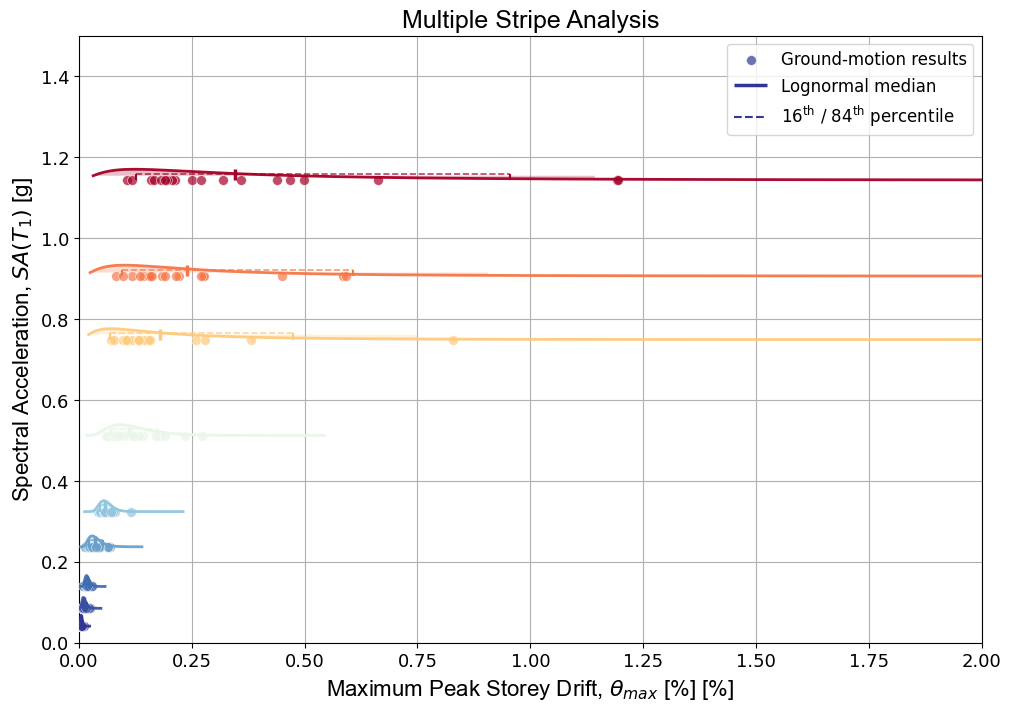

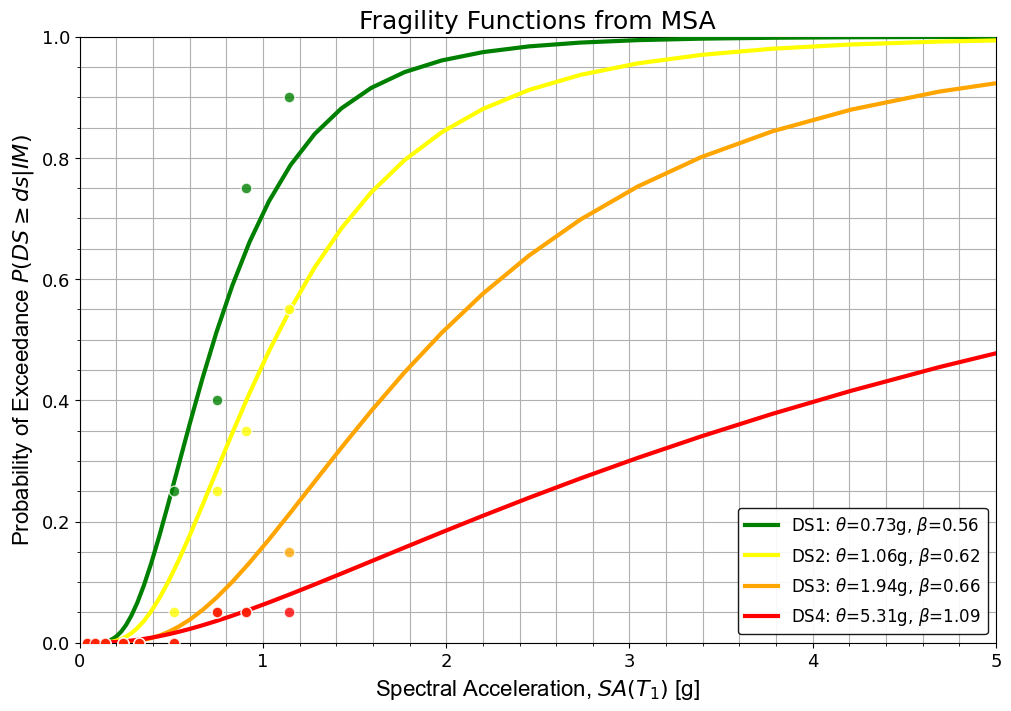

In [8]:
# Initialise the plotter class
pl = plotter()

# Plot the MSA stripes
pl.plot_msa_analysis(imls_matrix,
                     edps_matrix,
                     imt_label=r'Spectral Acceleration, $SA(T_{1})$ [g]',
                     edp_label=r'Maximum Peak Storey Drift, $\mu_{max}$ [%]',
                     xlims=[0, 2.0],
                     ylims=[0, 1.5],
                     title='Multiple Stripe Analysis',
                     pFlag=True,
                     export_path='out/msa_stripes.png')

pl.plot_fragility_from_msa(msa_dict,
                           imt_label=r'Spectral Acceleration, $SA(T_{1})$ [g]',
                           title='Fragility Functions from MSA',
                           xlims=[0, 5],
                           ylims=[0, 1],
                           pFlag=True,
                           export_path='out/fragility_curves.png')

## Post-Process Building-Level Vulnerability Functions based on Fragility Functions and Consequence Models ###

### Expected Loss Ratio (Mean Damage Ratio)

The vulnerability function expresses the expected loss ratio as a function of an intensity measure level (IM) and is obtained by convolving fragility functions with damage-to-loss ratios associated with each damage state.
Let $P(DS = ds_i \mid IM)$ denote the probability of the structure being in damage state $ds_i$ at a given intensity measure level $IM$, and let $\mu_{LR,i}$ be the mean loss ratio associated with that damage state. The expected loss ratio at intensity level $IM$, denoted as $E[LR \mid IM]$, is defined as

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM),\mu_{LR,i}
$$

where:

* $N_{DS}$ is the total number of discrete damage states
* $P(DS = ds_i \mid IM)$ is derived from the fragility functions
* $\mu_{LR,i}$ is the mean loss ratio associated with damage state $ds_i$


#### Step 1: Calculate Damage-State Probabilities (i.e., Probabilities of Occurrence) from Fragility Functions

Fragility functions are commonly expressed in terms of probabilities of exceedance. The probability of being in a specific damage state is computed as

$$
P(DS = ds_i \mid IM) =
\begin{cases}
P(DS \ge ds_i \mid IM) - P(DS \ge ds_{i+1} \mid IM), & i < N_{DS} \
P(DS \ge ds_{N_{DS}} \mid IM), & i = N_{DS}
\end{cases}
$$

Assuming lognormal fragility functions, the probability of exceeding damage state $ds_i$ is given by

$$
P(DS \ge ds_i \mid IM) = 
\Phi\left(
\frac{\ln(IM) - \ln(\mu_{ds_i})}
{\beta_{ds_i}^{\text{total}}}
\right)
$$

where:

* $\mu_{ds_i}$ is the median intensity measure corresponding to damage state $ds_i$
* $\beta_{ds_i}^{\text{total}}$ is the total logarithmic standard deviation
* $\Phi(\cdot)$ is the standard normal cumulative distribution function

The total dispersion is computed as

$$
\beta_{ds_i}^{\text{total}} = 
\sqrt{
\beta_{\text{record-to-record}}^2
+
\beta_{\text{building-to-building}}^2
+
\beta_{\text{DS}}^2
}
$$

where:

* $\beta_{\text{record-to-record}}$ (or $\beta_{\text{EDP}\mid IM}$) represents ground-motion variability
* $\beta_{\text{building-to-building}}$ (or $\beta_{\text{MDL}}$) captures model and structural variability
* $\beta_{\text{DS}}$ represents uncertainty in damage-state definition and thresholds


#### Step 2: Calculation of Uncertainty in Expected Loss

#### Method 1: Silva [5] (Semi-Empirical)

When uncertainty in the damage-to-loss relationship is not explicitly modelled, the dispersion of the loss ratio conditional on the intensity measure can be estimated using the empirical formulation proposed by Silva [5].
The coefficient of variation of the loss ratio conditional on $IM$ is defined as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{\sigma_{LR \mid IM}}{E[LR \mid IM]}
$$

Following Silva [5], the standard deviation of the loss ratio is expressed as a function of the mean loss ratio:

$$
\sigma_{LR \mid IM} = 
0.5
\sqrt{
\overline{LR}_{\mid IM}
\left(
-0.7
* 2,\overline{LR}_{\mid IM}
- \sqrt{6.8,\overline{LR}_{\mid IM} + 0.5}
  \right)
  }
$$

where $\overline{LR}_{\mid IM}$ denotes the mean loss ratio conditional on the intensity measure level. This approach provides a conservative envelope for loss uncertainty and is commonly adopted when detailed loss information is unavailable.


#### Method 2: Explicit Statistical Propagation

Alternatively, the uncertainty in the expected loss ratio can be quantified by explicitly propagating uncertainty through the convolution of damage-state probabilities and damage-to-loss ratios. In this formulation, fragility functions account for uncertainty in structural response and damage-state thresholds, while additional uncertainty arises from variability in the damage-to-loss ratios associated with each damage state. The expected loss ratio conditional on $IM$ is given by

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM),\mu_{LR,i}
$$

Assuming the loss ratio conditional on each damage state is an independent random variable with coefficient of variation $\mathrm{COV}_{LR,i}$, the variance of the loss ratio conditional on $IM$ is computed using the **law of total variance**:

$$
\mathrm{Var}(LR \mid IM) = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM)
\left[
\sigma_{LR,i}^2
+
\left(
\mu_{LR,i} - E[LR \mid IM]
\right)^2
\right]
$$

where

$$
\sigma_{LR,i} =
\mathrm{COV}*{LR,i},\mu*{LR,i}
$$

The coefficient of variation of the loss ratio conditional on the intensity measure is then computed as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{
\sqrt{\mathrm{Var}(LR \mid IM)}
}{
E[LR \mid IM]
}
$$

This formulation captures both:

* uncertainty **within damage states** due to variability in damage-to-loss ratios, and
* uncertainty due to **damage-state mixing** as intensity varies.


### Note on Beta-Distribution Interpretation of the Vulnerability Function

The loss ratio conditional on intensity measure level $IM$ is assumed to follow a **Beta distribution** as one option in the OpenQuake Engine <dist='BT'> (https://docs.openquake.org/oq-engine/3.23/manual/user-guide/inputs/vulnerability-models-inputs.html), owing to its bounded support on the interval $[0,1]$ and its flexibility in representing skewed distributions.

$$
LR \mid IM \sim \mathrm{Beta}(\alpha(IM), \beta(IM))
$$

The Beta distribution parameters are obtained by matching the first two moments:

$$
\mu(IM) = E[LR \mid IM]
$$

$$
\sigma^2(IM) = \mathrm{Var}(LR \mid IM)
$$

Defining the precision parameter

$$
\kappa(IM) = \alpha(IM) + \beta(IM)
$$

the Beta parameters are computed as

$$
\kappa(IM) =
\frac{\mu(IM),[1-\mu(IM)]}{\sigma^2(IM)} - 1
$$

$$
\alpha(IM) = \mu(IM),\kappa(IM),
\qquad
\beta(IM) = [1-\mu(IM)],\kappa(IM)
$$

This assumption enables a complete probabilistic characterization of loss conditional on intensity measure level and is particularly suitable for risk calculations, loss aggregation, and Monte Carlo simulation within performance-based engineering frameworks.

In [9]:
# Define consequence model to relate structural damage to a decision
# variable (i.e., expected loss ratio)
consequence_model = [0.05, 0.20, 0.60, 1.00]  # damage-to-loss ratios

# Define the uncertainty associated with each damage-to-loss ratio via coefficients of variation
consequence_cov = [0.30, 0.25, 0.20, 0.00]

# Calculate the structural vulnerability function (using the explicit method)
structural_vulnerability_explicit_cov = pp.calculate_vulnerability_function(
    msa_dict['fragility']['poes'][:, :4],  # poes columns 1-4: DS1 to DS4
    consequence_model,
    cov_consequence=consequence_cov,
    uncertainty=True,
    method='explicit',
)

# Calculate the structural vulnerability function (using the Silva (2019) method)
structural_vulnerability_silva_cov = pp.calculate_vulnerability_function(
    msa_dict['fragility']['poes'][:, :4],  # poes columns 1-4: DS1 to DS4
    consequence_model,
    uncertainty=True,
    method='silva',
)

## Plot the Vulnerability Functions with Uncertainty Visualisation ##

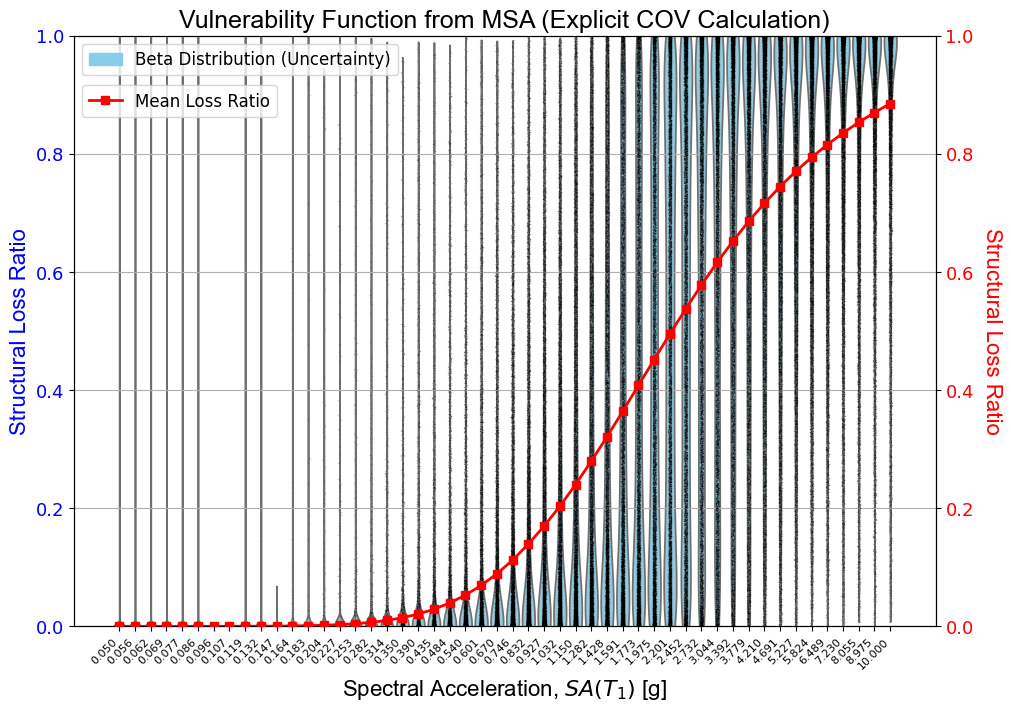

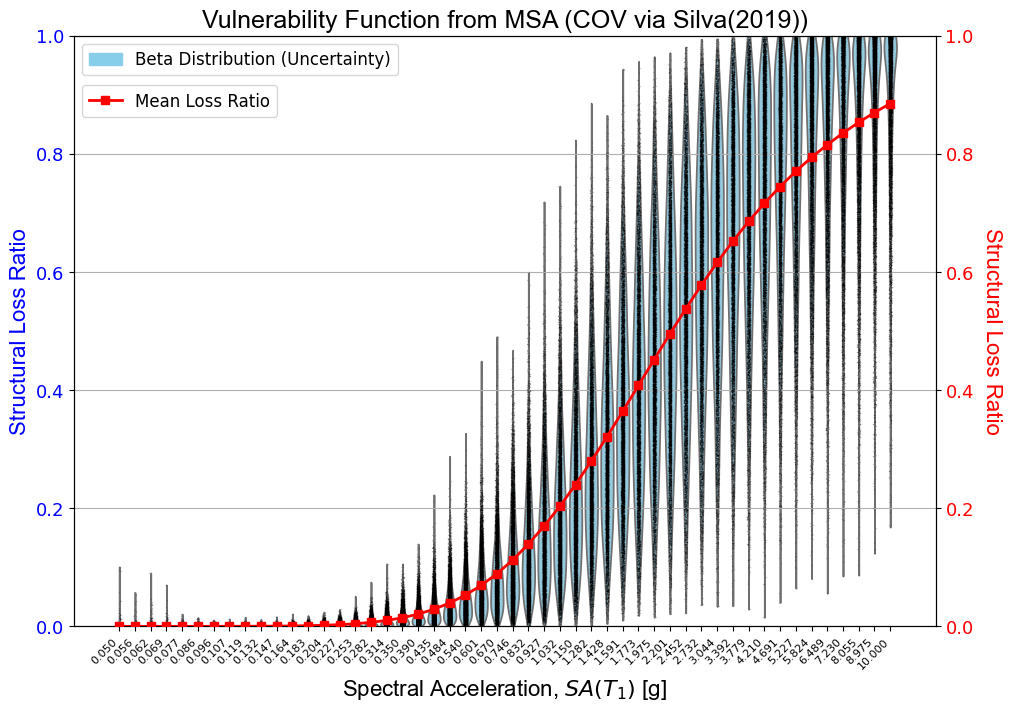

In [10]:
# Plot the structural vulnerability function from the explicit COV method
pl.plot_vulnerability_function(structural_vulnerability_explicit_cov['IML'],
                               structural_vulnerability_explicit_cov['Loss'],
                               structural_vulnerability_explicit_cov['COV'],
                               imt_label=r'Spectral Acceleration, $SA(T_{1})$ [g]',
                               loss_label='Structural Loss Ratio',
                               title='Vulnerability Function from MSA (Explicit COV Calculation)',
                               pFlag=True,
                               export_path='out/vulnerability_curve_explicit_cov.png')

# Plot the structural vulnerability function from the 'Silva (2019)' method
pl.plot_vulnerability_function(structural_vulnerability_silva_cov['IML'],
                               structural_vulnerability_silva_cov['Loss'],
                               structural_vulnerability_silva_cov['COV'],
                               imt_label=r'Spectral Acceleration, $SA(T_{1})$ [g]',
                               loss_label='Structural Loss Ratio',
                               title='Vulnerability Function from MSA (COV via Silva(2019))',
                               pFlag=True,
                               export_path='out/vulnerability_curve_silva_cov.png')